In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile
import os

zip_file = "archive (1).zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("water_dataset")

print("ZIP file extracted successfully!")
print(os.listdir("water_dataset"))

ZIP file extracted successfully!
['water_potability.csv']


In [ ]:
import pandas as pd

df = pd.read_csv("water_dataset/water_potability.csv")

df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
df.shape

(3276, 10)

In [ ]:
df.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [ ]:
df = df.fillna(df.median(numeric_only=True))

In [ ]:
df.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


In [10]:
df["Potability"].value_counts()

,count
Potability,
0,1998
1,1278


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

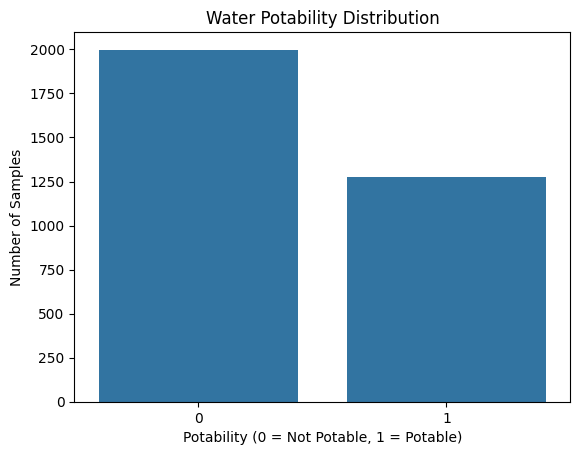

In [13]:
sns.countplot(x="Potability", data=df)

plt.title("Water Potability Distribution")
plt.xlabel("Potability (0 = Not Potable, 1 = Potable)")
plt.ylabel("Number of Samples")

plt.show()

In [14]:
X = df.drop("Potability", axis=1)
y = df["Potability"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2620, 9)
Testing data: (656, 9)


In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [17]:
y_pred = model.predict(X_test)

print("Prediction completed!")

Prediction completed!


In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.6737804878048781
Accuracy Percentage: 67.3780487804878 %


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.85      0.77       412
           1       0.60      0.38      0.46       244

    accuracy                           0.67       656
   macro avg       0.65      0.61      0.61       656
weighted avg       0.66      0.67      0.65       656



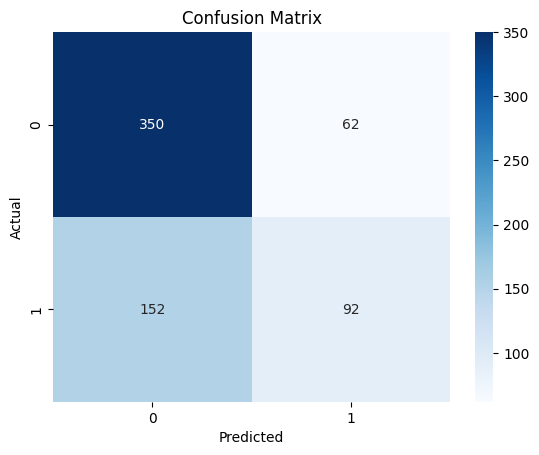

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

Sulfate            0.126330
ph                 0.126106
Hardness           0.119346
Chloramines        0.115096
Solids             0.114246
Conductivity       0.103434
Organic_carbon     0.102947
Turbidity          0.096463
Trihalomethanes    0.096031
dtype: float64


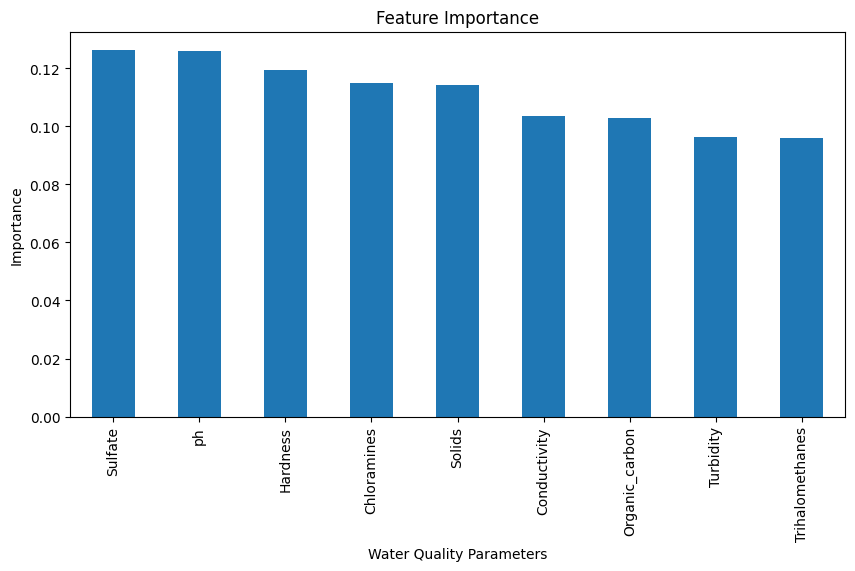

In [23]:
importance.plot(kind="bar", figsize=(10,5))

plt.title("Feature Importance")
plt.xlabel("Water Quality Parameters")
plt.ylabel("Importance")

plt.show()

In [24]:
new_water = pd.DataFrame({
    "ph": [7.0],
    "Hardness": [200],
    "Solids": [20000],
    "Chloramines": [7.0],
    "Sulfate": [350],
    "Conductivity": [400],
    "Organic_carbon": [10],
    "Trihalomethanes": [60],
    "Turbidity": [4]
})

prediction = model.predict(new_water)

if prediction[0] == 1:
    print("Water Quality: POTABLE")
else:
    print("Water Quality: NOT POTABLE")

Water Quality: NOT POTABLE
